# Taller de Aprendizaje No Supervisado
## Parte 2: Segmentación de Clientes de Tarjeta de Crédito (variables numéricas)

Resume el comportamiento de uso de unos **9.000 titulares** de tarjeta durante los últimos 6 meses, con **17 variables numéricas** (saldo, compras, adelantos de efectivo, límite de crédito, pagos...).

> **Diferencia clave con el dataset de setas:** aquí **no hay etiqueta**. El objetivo es encontrar segmentos de clientes para definir una estrategia de marketing. No podemos calcular ARI; nos guiamos por métricas internas y por la **interpretabilidad** de los segmentos.

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import IsolationForest
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage
from matplotlib.lines import Line2D

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

### Leer conjunto de datos y primer vistazo

In [2]:
df = pd.read_csv('data/credit_card.csv')
display(df.head())

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


### Exploración de datos

In [3]:
print(df.shape)

(8950, 18)


In [4]:
# Descripcion estadistica. Fijaos en las escalas tan distintas entre variables.
display(df.describe())

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


In [5]:
# Tipos de datos.
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

None

#### Nulos

In [6]:
# Contar nulos por variable (mostrad solo las que tengan).
display(df.isnull().sum()[df.isnull().sum() > 0])

CREDIT_LIMIT          1
MINIMUM_PAYMENTS    313
dtype: int64

Hay nulos en `CREDIT_LIMIT` (1) y `MINIMUM_PAYMENTS` (~313). Al ser variables numéricas muy sesgadas, los imputamos con la **mediana** (más robusta que la media).

In [7]:
# 1. Eliminar CUST_ID (es un identificador)
# 2. Imputar los nulos con la mediana de cada columna
if 'CUST_ID' in df.columns:
    df = df.drop(columns=['CUST_ID'])

df = df.fillna(df.median(numeric_only=True))
print(f"Nulos restantes: {df.isnull().sum().sum()}")

Nulos restantes: 0


#### Distribución de algunas variables

Muchas variables están **muy sesgadas** (la mayoría de clientes gasta poco y unos pocos muchísimo). Esto es típico en datos financieros.

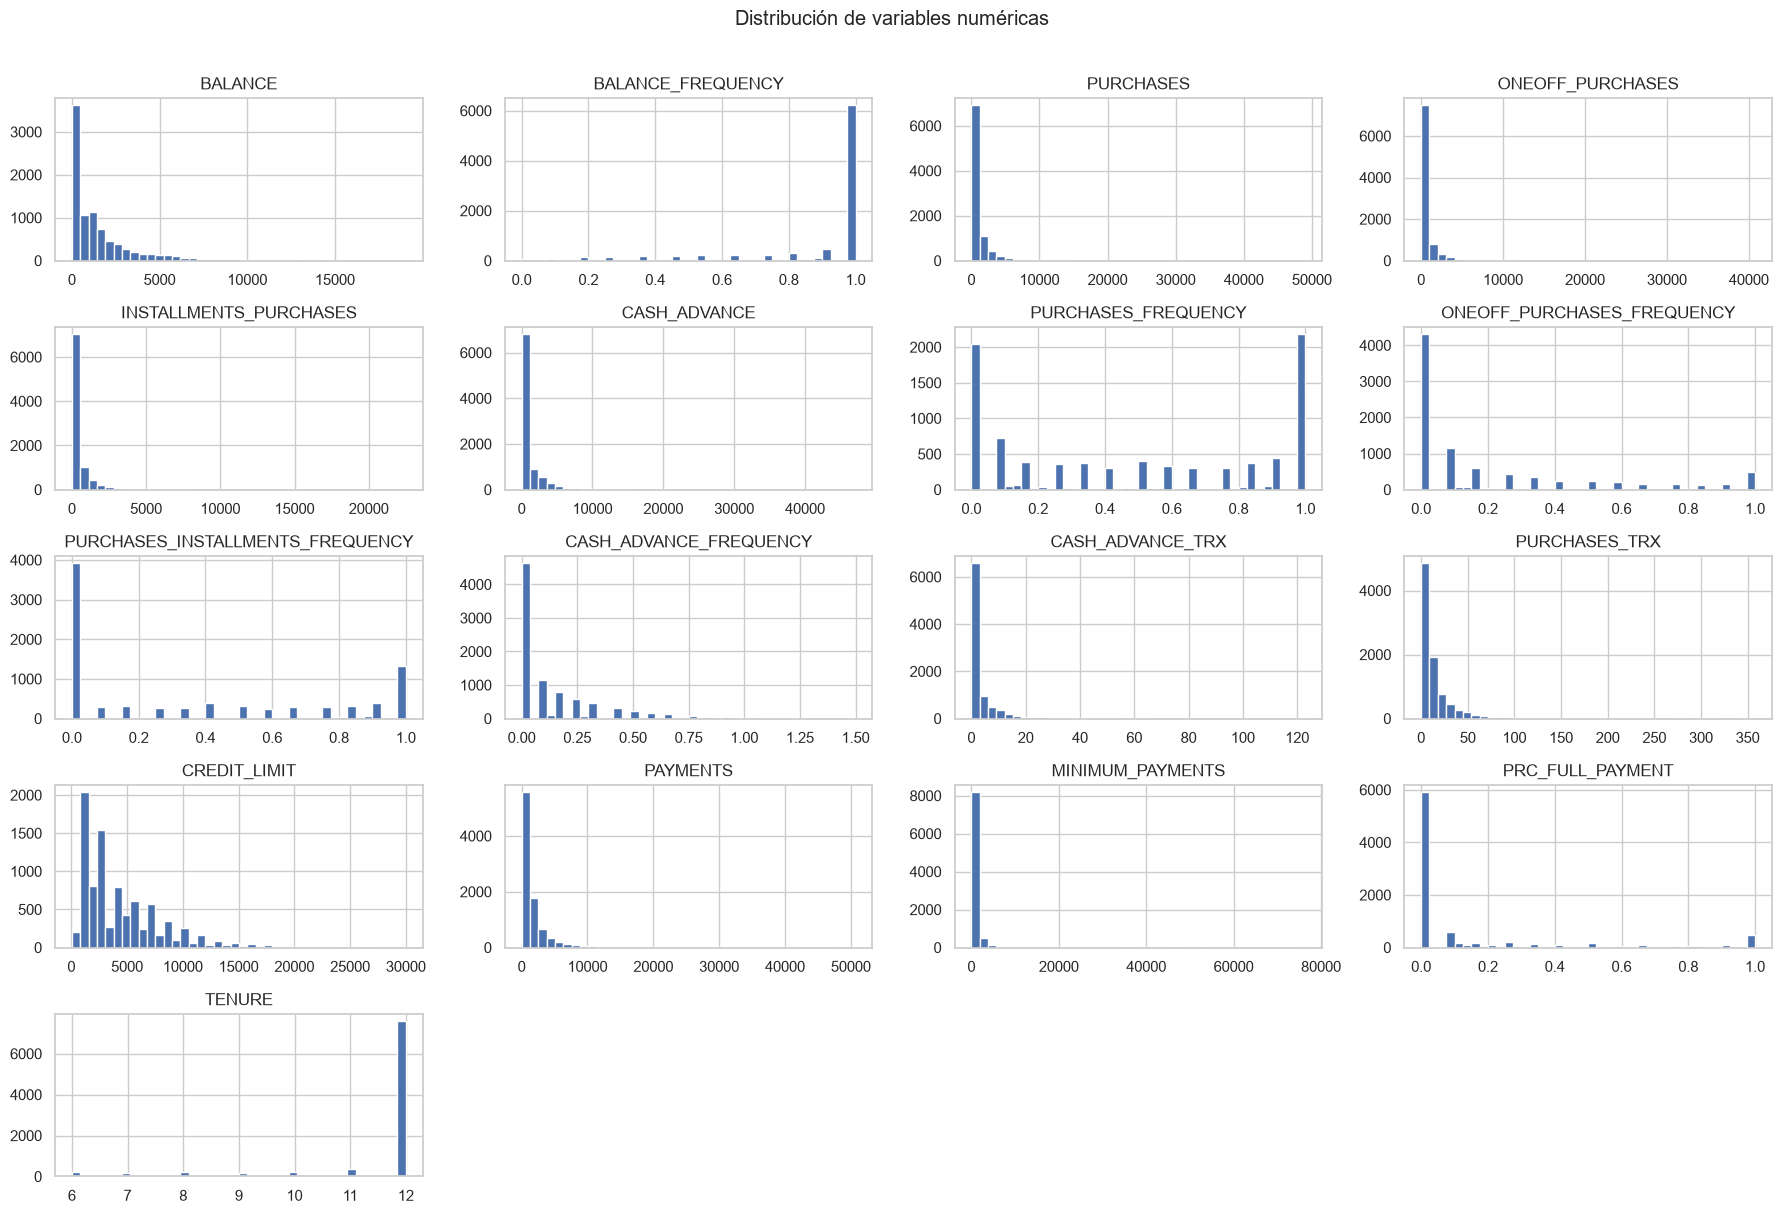

In [8]:
# Pintar histogramas de unas cuantas variables y observar el sesgo.
df.hist(bins=40, figsize=(18, 12), layout=(-1, 4))
plt.suptitle('Distribución de variables numéricas', y=1.01)
plt.tight_layout()
plt.show()

### Escalado

K-Means, PCA y casi todos los algoritmos de distancia son **sensibles a la escala**. `CREDIT_LIMIT` llega a miles y `PURCHASES_FREQUENCY` está entre 0 y 1: sin escalar, las variables grandes dominarían. Estandarizamos (media 0, desviación 1).

In [9]:
# Aplicar StandardScaler a df -> X (array escalado)
scaler = StandardScaler()
X = scaler.fit_transform(df)
print(f"Shape: {X.shape}")

Shape: (8950, 17)


## PCA

Con 17 variables no podemos pintar un scatter directo. Usamos PCA para (1) ver cuánta información retiene cada componente y (2) proyectar a 2D.

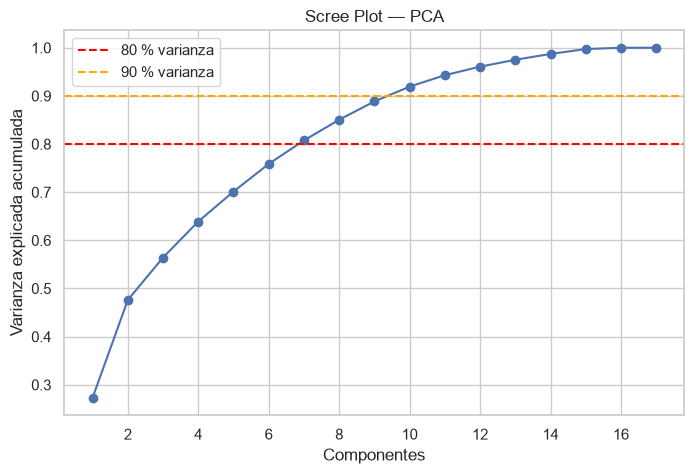

Componentes para 80% varianza: 7
Componentes para 90% varianza: 10


In [10]:
# 1. Ajustar PCA sin fijar n_components y mirar explained_variance_ratio_
# 2. Pintar la varianza explicada acumulada (scree plot)
# 3. Decidir cuantas componentes hacen falta para ~80% de varianza
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X)
var_acum = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(var_acum) + 1), var_acum, marker='o')
plt.axhline(0.80, color='red', linestyle='--', label='80 % varianza')
plt.axhline(0.90, color='orange', linestyle='--', label='90 % varianza')
plt.xlabel('Componentes'); plt.ylabel('Varianza explicada acumulada')
plt.title('Scree Plot — PCA')
plt.legend(); plt.grid(True); plt.show()

n_comp_80 = int(np.argmax(var_acum >= 0.80)) + 1
n_comp_90 = int(np.argmax(var_acum >= 0.90)) + 1
print(f"Componentes para 80% varianza: {n_comp_80}")
print(f"Componentes para 90% varianza: {n_comp_90}")

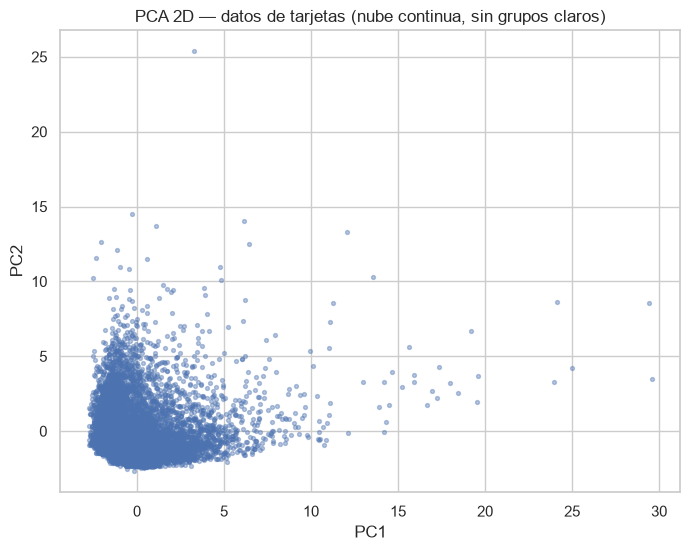

In [11]:
# Proyectar X a 2 componentes y pintar el scatter (aun sin colores: no hay etiqueta)
pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_vis = pca2.fit_transform(X)

plt.figure(figsize=(8, 6))
plt.scatter(X_vis[:, 0], X_vis[:, 1], s=8, alpha=0.4)
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title('PCA 2D — datos de tarjetas (nube continua, sin grupos claros)')
plt.show()

A diferencia de las setas, aquí no vemos grupos separados a simple vista: es más bien una **nube continua**. El clustering nos ayudará a trazar fronteras útiles dentro de ella.

## Clustering: ¿cuántos segmentos? Codo + Silhouette

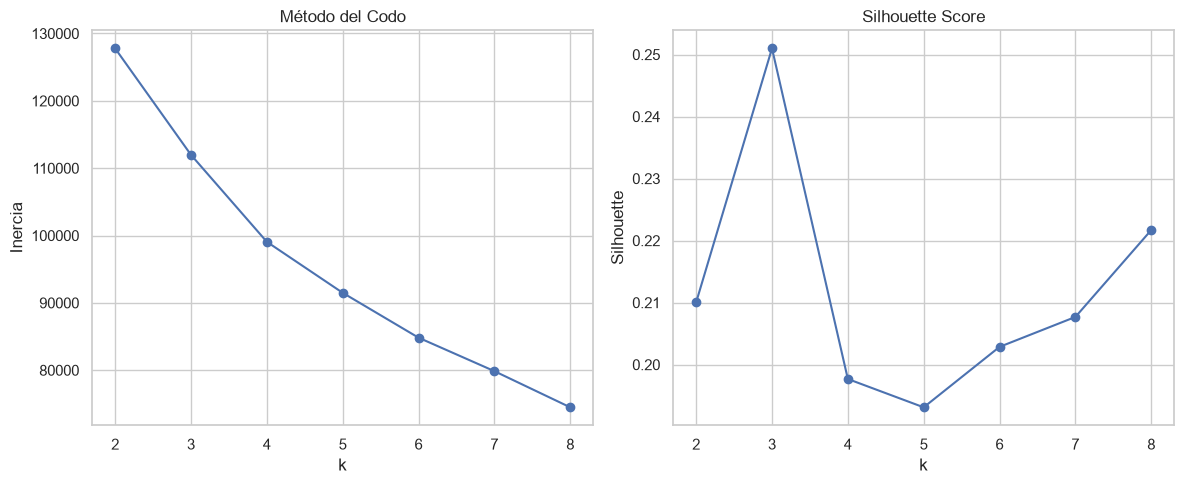

k óptimo según silhouette: 3


In [12]:
k_values = range(2, 9)
inercias, silhouettes = [], []
for k in k_values:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X)
    inercias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(k_values, inercias, marker='o')
axes[0].set(xlabel='k', ylabel='Inercia', title='Método del Codo')
axes[1].plot(k_values, silhouettes, marker='o')
axes[1].set(xlabel='k', ylabel='Silhouette', title='Silhouette Score')
plt.tight_layout(); plt.show()

best_k = int(np.argmax(silhouettes)) + 2
print(f"k óptimo según silhouette: {best_k}")

### K-Means final

In [13]:
# Entrenar KMeans con best_k, guardar las etiquetas y mirar el tamaño de cada cluster
kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
labels_km = kmeans.fit_predict(X)
print(pd.Series(labels_km).value_counts().sort_index().rename('Tamaño cluster'))

0    1275
1    6114
2    1561
Name: Tamaño cluster, dtype: int64


### Comparativa de algoritmos

Sin etiqueta, comparamos con **métricas internas**: *silhouette* y *Calinski-Harabasz* (más alto = mejor) y *Davies-Bouldin* (más bajo = mejor).

In [14]:
# Definir evaluar(nombre, labels, X) con silhouette, davies_bouldin y calinski_harabasz
# (sin ARI: no hay etiqueta). Comparar KMeans, Aglomerativo y GMM.
def evaluar(nombre, labels, X_data):
    n_cl = len(set(labels)) - (1 if -1 in labels else 0)
    mask = labels != -1
    sil = db = ch = np.nan
    if n_cl >= 2 and mask.sum() >= 2:
        try:
            sil = silhouette_score(X_data[mask], labels[mask])
            db  = davies_bouldin_score(X_data[mask], labels[mask])
            ch  = calinski_harabasz_score(X_data[mask], labels[mask])
        except ValueError:
            pass
    return {
        'Algoritmo': nombre, 'N_Clusters': n_cl,
        'Silhouette ↑': round(sil, 4) if not np.isnan(sil) else np.nan,
        'Davies-Bouldin ↓': round(db, 4) if not np.isnan(db) else np.nan,
        'Calinski-Harabasz ↑': round(ch, 2) if not np.isnan(ch) else np.nan
    }

results = []
results.append(evaluar(f'KMeans (k={best_k})', labels_km, X))

labels_agg = AgglomerativeClustering(n_clusters=best_k).fit_predict(X)
results.append(evaluar(f'Aglomerativo (k={best_k})', labels_agg, X))

labels_gmm = GaussianMixture(n_components=best_k, random_state=RANDOM_STATE).fit_predict(X)
results.append(evaluar(f'GMM (k={best_k})', labels_gmm, X))

display(pd.DataFrame(results))

,Algoritmo,N_Clusters,Silhouette ↑,Davies-Bouldin ↓,Calinski-Harabasz ↑
0,KMeans (k=3),3,0.2510,1.5920,1605.03
1,Aglomerativo (k=3),3,0.1674,1.8496,1239.33
2,GMM (k=3),3,0.0978,2.9968,815.78


### Dendrograma

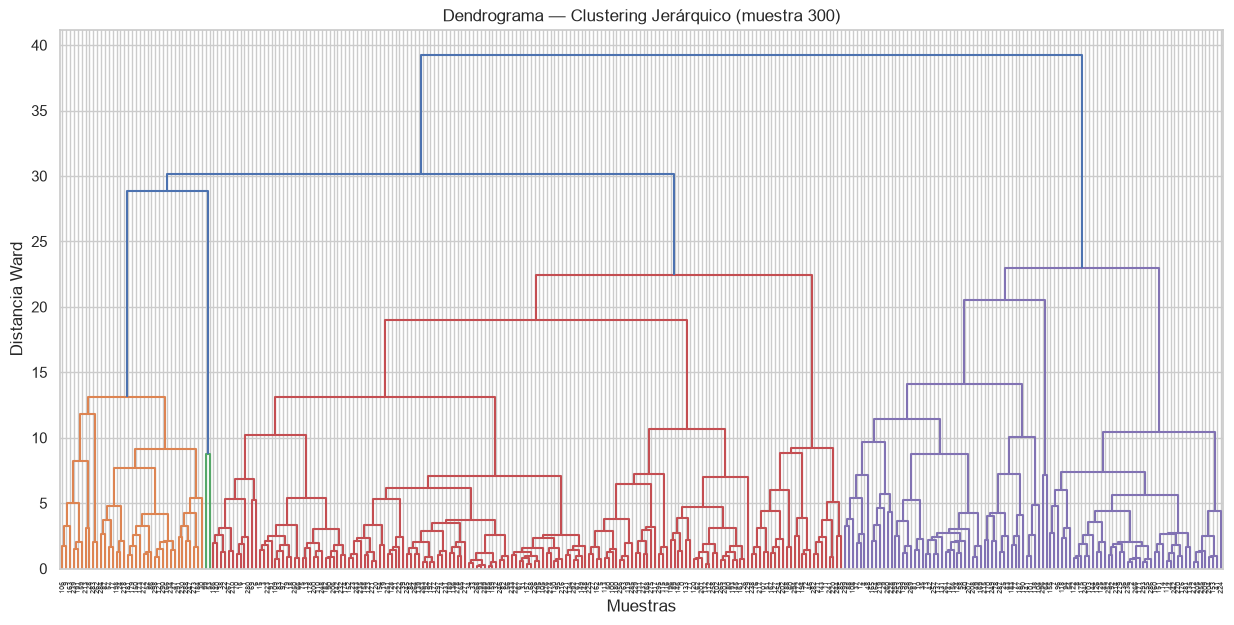

In [15]:
# linkage + dendrogram sobre una muestra de X
np.random.seed(RANDOM_STATE)
idx = np.random.choice(X.shape[0], 300, replace=False)
linked = linkage(X[idx], method='ward')

plt.figure(figsize=(15, 7))
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=True)
plt.title('Dendrograma — Clustering Jerárquico (muestra 300)')
plt.xlabel('Muestras'); plt.ylabel('Distancia Ward')
plt.show()

### DBSCAN: ¿hay clusters de densidad aquí?

Probamos DBSCAN. Veréis que en alta dimensión tiende a juntar casi todo en **un solo cluster** y marcar el resto como **ruido**. Eso nos dice algo importante: estos datos son una nube continua, no grupos separados por densidad. Aquí DBSCAN funciona mejor como **detector de atípicos** que como segmentador.

In [16]:
# Ejecutar DBSCAN sobre la proyeccion PCA(2). Observar cuantos clusters y cuanto ruido.
labels_db = DBSCAN(eps=0.5, min_samples=5).fit_predict(X_vis)
n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise_db = (labels_db == -1).sum()
print(f"Clusters encontrados: {n_clusters_db}  |  Puntos de ruido: {n_noise_db}")

Clusters encontrados: 5  |  Puntos de ruido: 134


### Visualización de los segmentos (t-SNE)

Proyectamos con t-SNE (sobre una muestra) y coloreamos por el segmento de K-Means.

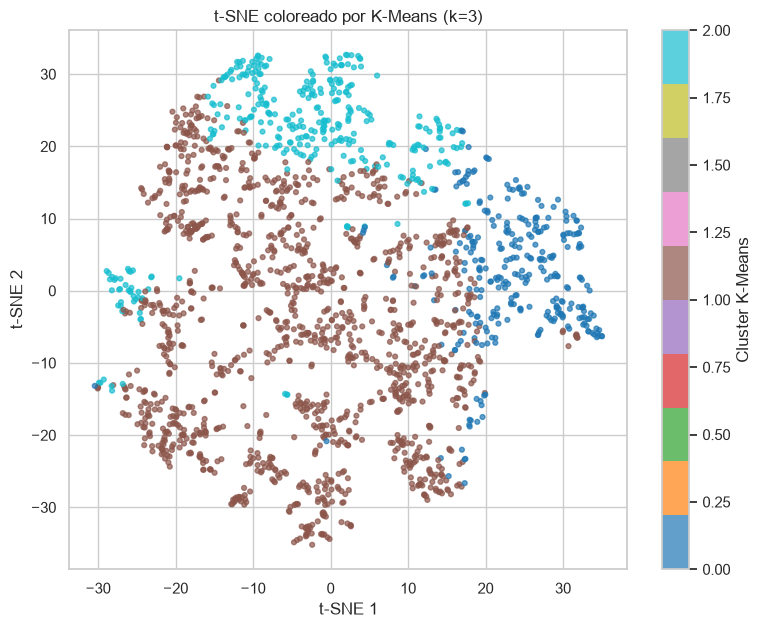

In [17]:
# t-SNE sobre una muestra de X, coloreado por el cluster de KMeans
np.random.seed(RANDOM_STATE)
idx_tsne = np.random.choice(X.shape[0], min(2000, X.shape[0]), replace=False)
tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30, max_iter=500)
X_tsne = tsne.fit_transform(X[idx_tsne])

plt.figure(figsize=(9, 7))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels_km[idx_tsne],
                      cmap='tab10', s=12, alpha=0.7)
plt.colorbar(scatter, label='Cluster K-Means')
plt.title(f't-SNE coloreado por K-Means (k={best_k})')
plt.xlabel('t-SNE 1'); plt.ylabel('t-SNE 2')
plt.show()

## Interpretación de los segmentos

Lo más importante en segmentación: **¿qué caracteriza a cada grupo?** Calculamos la media de cada variable por cluster y la estandarizamos entre clusters (rojo = por encima de la media, azul = por debajo). Así leemos el «perfil» de cada segmento.

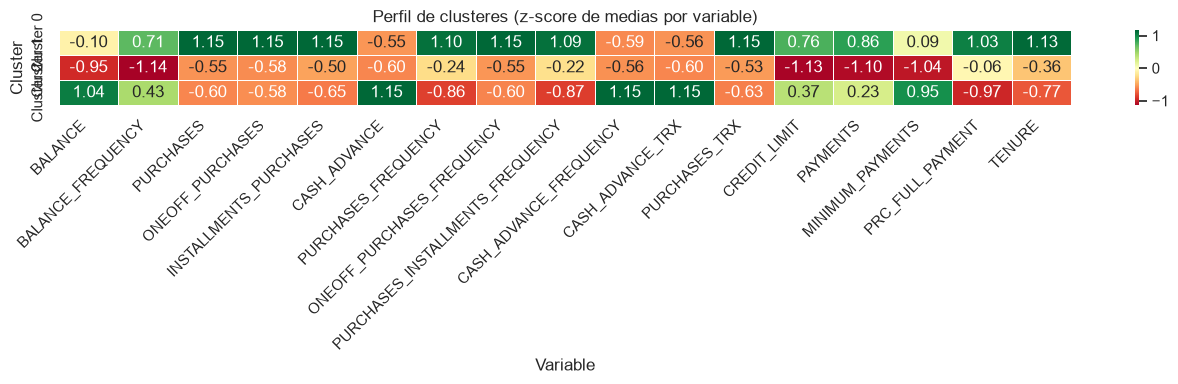

In [18]:
# 1. Anadir la columna cluster al df original (sin escalar)
# 2. Calcular la media de cada variable por cluster
# 3. Estandarizar entre clusters y pintar un heatmap (perfil de cada segmento)
df_perfil = df.copy()
df_perfil["Cluster"] = labels_km

medias = df_perfil.groupby("Cluster").mean()
medias_norm = (medias - medias.mean()) / medias.std()

# Clusters en filas, variables en columnas -> orientacion intuitiva
plt.figure(figsize=(max(12, len(medias_norm.columns) * 0.8), max(4, best_k * 1.2)))
sns.heatmap(medias_norm, annot=True, fmt=".2f", cmap="RdYlGn",
            linewidths=0.5, center=0,
            xticklabels=medias_norm.columns,
            yticklabels=[f"Cluster {i}" for i in medias_norm.index])
plt.title("Perfil de clusteres (z-score de medias por variable)")
plt.ylabel("Cluster"); plt.xlabel("Variable")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Leyendo el heatmap se pueden nombrar los segmentos en términos de **negocio**, por ejemplo: clientes de alto saldo y muchas compras (VIP), clientes que tiran de adelantos de efectivo (riesgo), clientes poco activos, etc. Ese nombre y la estrategia asociada es justo el entregable que pide el caso.

| Cluster | Perfil | Nombre sugerido |
|---------|--------|-----------------|
| 0 | … | … |
| 1 | … | … |

> Completa la tabla según los clusters reales que obtengas.

## Detección de anomalías (Isolation Forest)

Identificamos los clientes con comportamiento más atípico (posible fraude, errores de datos o clientes premium fuera de norma).

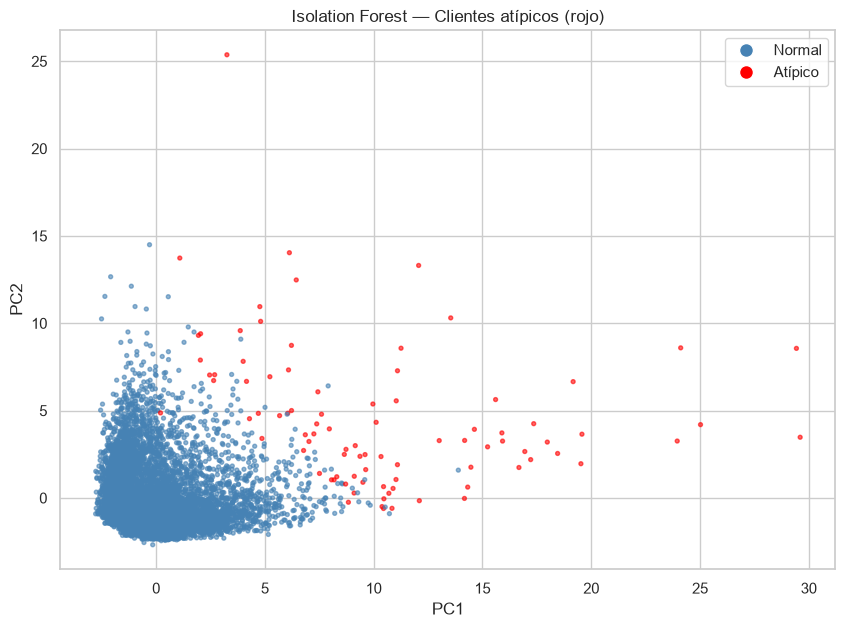

Clientes atípicos detectados: 90


In [19]:
# IsolationForest sobre X, marcar los atipicos (-1) y pintarlos sobre PCA(2)
iso = IsolationForest(contamination=0.01, random_state=RANDOM_STATE)
preds = iso.fit_predict(X)

colors = np.where(preds == 1, 'steelblue', 'red')
plt.figure(figsize=(10, 7))
plt.scatter(X_vis[:, 0], X_vis[:, 1], c=colors, s=8, alpha=0.6)
plt.title('Isolation Forest — Clientes atípicos (rojo)')
plt.xlabel('PC1'); plt.ylabel('PC2')
legend_els = [Line2D([0],[0], marker='o', color='w', markerfacecolor='steelblue', markersize=10, label='Normal'),
              Line2D([0],[0], marker='o', color='w', markerfacecolor='red',       markersize=10, label='Atípico')]
plt.legend(handles=legend_els)
plt.show()
print(f"Clientes atípicos detectados: {(preds == -1).sum()}")

---
## Para ir más allá (opcional)

- **Ingeniería de KPIs**: derivar variables como *ratio de uso del límite* (`BALANCE / CREDIT_LIMIT`) o *compra media por transacción* suele mejorar mucho los segmentos.
- **UMAP / HDBSCAN** para visualización y clustering por densidad más robusto.
- **Transformación logarítmica** de las variables sesgadas antes de escalar.

## Conclusiones

- Sin etiqueta, la segmentación se valida con métricas internas (*silhouette*, etc.) y, sobre todo, con la **interpretabilidad** de los perfiles.
- Imputar y **escalar** fue imprescindible aquí (a diferencia de las setas).
- K-Means, GMM y Aglomerativo dan segmentos coherentes; DBSCAN reveló que los datos son una nube continua (mejor como detector de atípicos).
- El heatmap de perfiles convierte los clusters en **segmentos de negocio accionables**.